In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta

## 1

In [2]:
files_metadata = pd.read_csv('films_meta.tsv', sep='\t', header=0)
files_metadata['filename'] = files_metadata['eng title'].str.replace(":", "").replace(r"/", "")
files_metadata = files_metadata.drop(['json', 'path'], axis="columns")
#files_metadata = files_metadata.dropna()
files_metadata.to_csv('files_meta_2.csv')

In [3]:
#files_metadata = pd.read_csv('films_meta_corr.csv', header=0, index_col=0)

In [4]:
files_metadata

,year,genre,eng title,rus title,imdb,mark,rated,released,runtime,genres,directors,writers,actors,awards,filename
0,1990,action,The Hunt for Red October,Охота за Красным Октябрем,https://www.imdb.com/title/tt0099810/,"7,6",PG,02 Mar 1990,135 min,"Action, Adventure, Thriller",John McTiernan,"Tom Clancy, Larry Ferguson, Donald E. Stewart","Sean Connery, Alec Baldwin, Scott Glenn",Won 1 Oscar. 3 wins & 9 nominations total,The Hunt for Red October
1,1990,action,Total Recall,Вспомнить всё,https://www.imdb.com/title/tt0100802/,"7,5",R,01 Jun 1990,113 min,"Action, Adventure, Sci-Fi",Paul Verhoeven,"Philip K. Dick, Ronald Shusett, Dan O'Bannon","Arnold Schwarzenegger, Sharon Stone, Michael I...",Nominated for 2 Oscars. 7 wins & 16 nomination...,Total Recall
2,1990,action,Die Hard 2,Крепкий орешек 2,https://www.imdb.com/title/tt0099423/,"7,2",R,03 Jul 1990,124 min,"Action, Thriller",Renny Harlin,"Steven E. de Souza, Doug Richardson, Walter Wager","Bruce Willis, William Atherton, Bonnie Bedelia",1 win & 1 nomination total,Die Hard 2
3,1990,comedy,Rosencrantz & Guildenstern Are Dead,Розенкранц и Гильденстерн мертвы,https://www.imdb.com/title/tt0100519/,"7,5",PG,08 Feb 1991,117 min,"Comedy, Drama",Tom Stoppard,Tom Stoppard,"Gary Oldman, Tim Roth, Richard Dreyfuss",3 wins & 2 nominations total,Rosencrantz & Guildenstern Are Dead
4,1990,comedy,Home Alone,Один дома,https://www.imdb.com/title/tt0099785/,"7,6",PG,16 Nov 1990,103 min,"Comedy, Family",Chris Columbus,John Hughes,"Macaulay Culkin, Joe Pesci, Daniel Stern",Nominated for 2 Oscars. 12 wins & 7 nomination...,Home Alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,1999,thriller,The Sixth Sense,Шестое чувство,https://www.imdb.com/title/tt0167404/,"8,1",PG-13,06 Aug 1999,107 min,"Drama, Mystery, Thriller",M. Night Shyamalan,M. Night Shyamalan,"Bruce Willis, Haley Joel Osment, Toni Collette",Nominated for 6 Oscars. 37 wins & 56 nominatio...,The Sixth Sense
294,1999,thriller,Eyes Wide Shut,С широко закрытыми глазами,https://www.imdb.com/title/tt0120663/,"7,4",R,16 Jul 1999,159 min,"Drama, Mystery, Thriller",Stanley Kubrick,"Stanley Kubrick, Frederic Raphael, Arthur Schn...","Tom Cruise, Nicole Kidman, Madison Eginton",12 wins & 30 nominations total,Eyes Wide Shut
295,1999,war,One Man's Hero,Герой-предатель,https://www.imdb.com/title/tt0120775/,"6,1",R,08 Oct 1999,121 min,"Action, Drama, History",Lance Hool,Milton S. Gelman,"Tom Berenger, Joaquim de Almeida, Daniela Romo",3 nominations,One Man's Hero
296,1999,war,Three Kings,Три короля,https://www.imdb.com/title/tt0120188/,"7,1",R,01 Oct 1999,114 min,"Action, Adventure, Comedy",David O. Russell,"John Ridley, David O. Russell","George Clooney, Mark Wahlberg, Ice Cube",8 wins & 19 nominations total,Three Kings


In [5]:
files_metadata['mark'] = files_metadata['mark'].apply(lambda x: float(x.replace(',', '.')))

<Axes: ylabel='Frequency'>

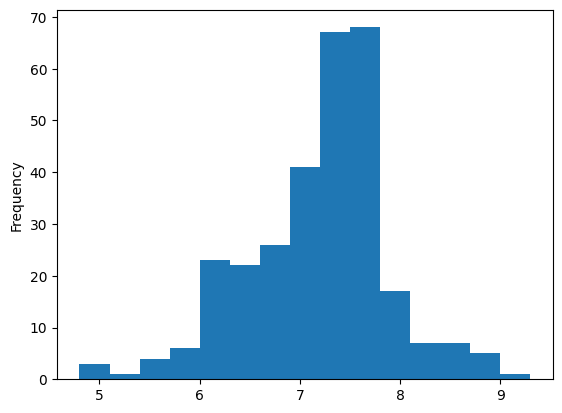

In [6]:
files_metadata['mark'].plot(kind='hist', bins=15)

<Axes: >

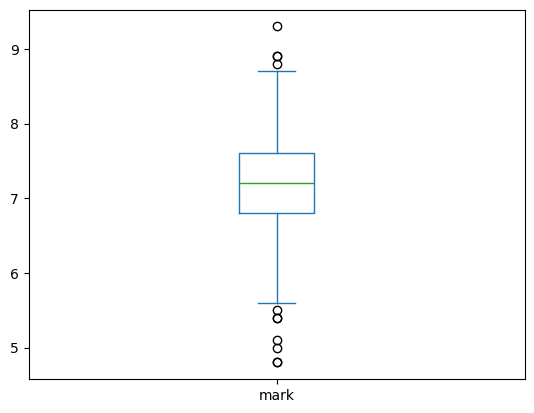

In [7]:
files_metadata['mark'].plot(kind='box')

In [8]:
files_metadata.sort_values('filename').loc[81]['filename']

'Universal Soldier'

In [9]:
files_metadata['genre'].unique()

<StringArray>
[  'action',   'comedy',    'crime',    'drama',  'history',   'horror',
  'romance',   'sci-fi', 'thriller',      'war']
Length: 10, dtype: str

In [10]:
files = os.listdir("shot_detection")

In [11]:
films_data = pd.DataFrame()

for file in files:
    df = pd.read_csv("shot_detection\\" + file, header=0)
    meta_filename = 'files_info\\info_' + file.split("shot-data_")[1]
    meta_df = pd.read_csv(meta_filename, index_col=0, header=None).T
    df['filename'] = file.replace(' .', '.')[10:-4]
    df['length'] = df['end'] - df['start']
    df['time_length'] = df['length'] / 24 # meta_df.iloc[0]['fps'] # по метаданным не во всех фильмах 24, можно взять в files_info
    df['timecode'] = df['start'].apply(lambda x: str(timedelta(seconds=x // 24))) 
    df['frame_count'] = int(meta_df.iloc[0]['frame_count'])
    df['height'] = int(meta_df.iloc[0]['height'])
    df['width'] = int(meta_df.iloc[0]['width'])
    films_data = pd.concat([films_data, df], axis=0, ignore_index=False)

In [12]:
films_data['filename'].nunique()

298

In [13]:
films_data = films_data.reset_index()
films_data.rename(columns={'index': 'shot_index'}, inplace=True)

In [14]:
films_data_ext = pd.merge(films_data, files_metadata, on='filename', how='left')

In [15]:
films_data_ext[films_data_ext['eng title'].isnull()]['filename'].unique() #проверяем, все ли файлы корректно сопоставлены

<StringArray>
[]
Length: 0, dtype: str

In [16]:
films_data['shot_count'] = films_data.groupby('filename')['shot_index'].transform('max')

In [17]:
films_data.sample(3)

,shot_index,start,end,filename,length,time_length,timecode,frame_count,height,width,shot_count
98652,2047,127557,127591,Enemy of the State,34,1.416667,1:28:34,190154,304,720,2972
313261,1368,161686,161717,The Game,31,1.291667,1:52:16,185056,400,720,1553
329133,1719,158202,158241,The Matrix,39,1.625000,1:49:51,196069,304,720,2085


In [18]:
films_data.to_csv("films_data.csv", index=False)

## 2

In [19]:
films_data = pd.read_csv('films_data.csv', header=0)

In [20]:
films_data.sample(3)

,shot_index,start,end,filename,length,time_length,timecode,frame_count,height,width,shot_count
260673,662,74063,74102,Sleepers,39,1.625000,0:51:25,211704,304,720,1746
355002,600,88105,88200,The Usual Suspects,95,3.958333,1:01:11,152585,304,720,1054
355174,772,115014,115047,The Usual Suspects,33,1.375000,1:19:52,152585,304,720,1054


In [21]:
titles_start = films_data[((films_data['end'] > films_data['frame_count'] - 7500) & (films_data['time_length'] > 60)) | (films_data['end'] > films_data['frame_count'] - 3000)].groupby(by='filename', as_index=False)['shot_index'].min()
titles_start = titles_start.rename(columns={'shot_index': 'titles_start'})
titles_start.head(3)

,filename,titles_start
0,10 Things I Hate About You,815
1,A Bronx Tale,1731
2,A Few Good Men,1466


In [22]:
len(titles_start)

298

In [23]:
films_data = pd.merge(films_data, titles_start, on='filename', how='left')

In [24]:
films_data = films_data[films_data['start'] > 700]

In [25]:
films_data = films_data[films_data['shot_index'] < films_data['titles_start']]

In [26]:
# films_data[((films_data['shot_index'] < 20) | (films_data['shot_index'] > films_data['shot_count'] - 20)) & (films_data['time_length'] > 50)].sort_values(by='filename').head(20)

In [27]:
films_data.sort_values(by='length').tail(15)

,shot_index,start,end,filename,length,time_length,timecode,frame_count,height,width,shot_count,titles_start
53583,79,83829,89241,Bullets Over Broadway,5412,225.500000,0:58:12,142177,480,856,167,127
263504,3,802,6223,Sling Blade,5421,225.875000,0:00:33,193065,384,720,324,323
27170,289,102562,107984,Bad Lieutenant,5422,225.916667,1:11:13,138428,400,720,351,337
80377,46,9223,14700,Deconstructing Harry,5477,228.208333,0:06:24,137491,464,704,311,294
263519,18,13992,19477,Sling Blade,5485,228.541667,0:09:43,193065,384,720,324,323
320306,294,44626,50128,The Last of the Mohicans,5502,229.250000,0:30:59,164789,480,1152,1123,1122
263719,218,98553,104342,Sling Blade,5789,241.208333,1:08:26,193065,384,720,324,323
308140,817,146944,153111,The Fisher King,6167,256.958333,1:42:02,198078,560,1024,1019,1019
263720,219,104343,110589,Sling Blade,6246,260.250000,1:12:27,193065,384,720,324,323
282218,920,132433,139450,Stir of Echoes,7017,292.375000,1:31:58,153032,528,704,1116,1079


In [28]:
# films_data.groupby('filename', as_index=False)['shot_index'].count().sort_values(by='shot_index').tail(15)

In [29]:
data_update = films_data.groupby(by='filename', as_index=False)[['start', 'end', 'shot_index']].agg(['min', 'max'])

data_update['frame_count'] = data_update['end']['max'] - data_update['start']['min'] + 1
data_update['shot_count'] = data_update['shot_index']['max'] - data_update['shot_index']['min'] + 1
data_update['shot_index_min'] = data_update['shot_index']['min']
data_update['film_start'] = data_update['start']['min']
data_update['film_end'] = data_update['end']['max']

In [30]:
data_update

filename start           end         shot_index        \
                                  min     max   min     max        min   max   
0    10 Things I Hate About You  1891  132763  1957  132877          2   814   
1                  A Bronx Tale  3855  159981  4459  160211          1  1730   
2                A Few Good Men   713  192991  1366  193174          4  1465   
3              A Midnight Clear   832  150664   991  151568          7   749   
4               A Perfect World  1104  191061  1263  191366          4  1736   
..                          ...   ...     ...   ...     ...        ...   ...   
293               Wild at Heart   902  174184  1739  174574          7   979   
294        Wisconsin Death Trip   856  107289   966  107626          3   591   
295                        Wolf  1701  172806  1703  172886          2   809   
296           Wuthering Heights   768  149736   819  149741          4   945   
297                      Xi yan  1539  146855  1728  147034          3   528   

    frame_count shot_count shot_index_min film_start film_end  
                                                               
0        130987        813              2       1891   132877  
1        156357       1730              1       3855   160211  
2        192462       1462              4        713   193174  
3        150737        743              7        832   151568  
4        190263       1733              4       1104   191366  
..          ...        ...            ...        ...      ...  
293      173673        973              7        902   174574  
294      106771        589              3        856   107626  
295      171186        808              2       1701   172886  
296      148974        942              4        768   149741  
297      145496        526              3       1539   147034  

[298 rows x 12 columns]

In [31]:
data_update = data_update[['filename', 'frame_count', 'shot_count','shot_index_min', 'film_start', 'film_end']]
data_update.columns = ['filename', 'frame_count', 'shot_count','shot_index_min', 'film_start', 'film_end']

In [32]:
data_update

,filename,frame_count,shot_count,shot_index_min,film_start,film_end
0,10 Things I Hate About You,130987,813,2,1891,132877
1,A Bronx Tale,156357,1730,1,3855,160211
2,A Few Good Men,192462,1462,4,713,193174
3,A Midnight Clear,150737,743,7,832,151568
4,A Perfect World,190263,1733,4,1104,191366
...,...,...,...,...,...,...
293,Wild at Heart,173673,973,7,902,174574
294,Wisconsin Death Trip,106771,589,3,856,107626
295,Wolf,171186,808,2,1701,172886
296,Wuthering Heights,148974,942,4,768,149741


In [33]:
film_diff = pd.merge(files_metadata, data_update, on='filename', how='left').dropna(subset=['filename'])

In [34]:
film_diff[film_diff['frame_count'].isna()]['filename'] # проблемные фильмы, из которых удалилось всё например - их нет

Series([], Name: filename, dtype: str)

In [35]:
films_data = films_data.drop(['frame_count', 'shot_count'], axis="columns")

In [36]:
films_data = pd.merge(films_data, data_update, on='filename', how='left')

In [37]:
films_data['shot_index'] = films_data['shot_index'] - films_data['shot_index_min']

In [38]:
films_data = films_data.drop(['shot_index_min', 'titles_start'], axis=1)

по сути: берем начало и конец фильма (новые начало и конец, после отрезания титров), вычисляем новую длину фильма (frame_count). потом мы делим frame_count на n, получаем

ну типа у нас есть 900 кадров фильм (но отсчёт от 1000) и n=9. тогда они меняются каждые 100 кадров (frame_count // n). то есть 1050-1000 = 50 // 100 = 0 + 1 = 1

1234 - 1000 = 234 // 100 = 2 + 1 = 3

234/900 = 0.3

In [39]:
int(((1834 - 1000) / 900 * 3) // 1 + 1)

3

In [40]:
films_data['part'] = films_data.apply(lambda row: int(((row['start'] - row['film_start']) /
                                                            row['frame_count'] * 3) // 1 + 1),
                                           axis=1)

In [41]:
films_data['part_of_6'] = films_data.apply(lambda row: int(((row['start'] - row['film_start']) /
                                                            row['frame_count'] * 6) // 1 + 1),
                                           axis=1)

In [42]:
films_data['part_of_9'] = films_data.apply(lambda row: int(((row['start'] - row['film_start']) /
                                                            row['frame_count'] * 9) // 1 + 1),
                                           axis=1)

In [43]:
films_data.sample(3)

,shot_index,start,end,filename,length,time_length,timecode,height,width,frame_count,shot_count,film_start,film_end,part,part_of_6,part_of_9
85863,589,66589,66662,Dick Tracy,73,3.041667,0:46:14,692,1280,143243,1407,1254,144496,2,3,5
308277,102,13369,13768,The Fugitive,399,16.625000,0:09:17,516,912,179953,1773,1109,181061,1,1,1
108885,142,39056,39209,Firelight,153,6.375000,0:27:07,288,704,142689,595,1477,144165,1,2,3


In [44]:
films_data.to_csv("films_data_without_titles.csv", index=False)

## 3

In [45]:
films_data['minute'] = films_data['timecode'].apply(lambda x: int(x.split(':')[0])*60 + int(x.split(':')[1]))

In [46]:
def plotline_minutes(filmname):
    plot_data = films_data[films_data['filename'] == filmname].groupby('minute')['time_length'].mean()
    plot_data.plot.line(x='minute', y='mean_time_length')

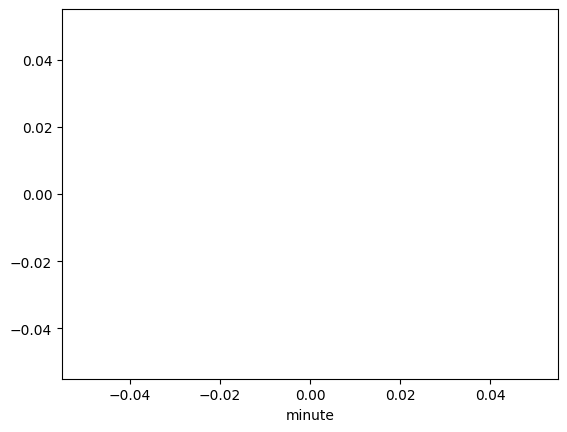

In [47]:
plotline_minutes("The Silence of the Lambs ")

In [48]:
films_data_filt = films_data[~(((films_data['shot_index'] < 20) | (films_data['shot_index'] > films_data['shot_count'] - 20)) & (films_data['time_length'] > 50))]
films_data_filt = films_data_filt.loc[(films_data['length'] < 15000)]

In [49]:
films_data_filt = films_data

In [50]:
def plotline(filmname):
    film = films_data_filt[films_data_filt['filename'] == filmname]
    film.plot.line(x='shot_index', y='time_length')

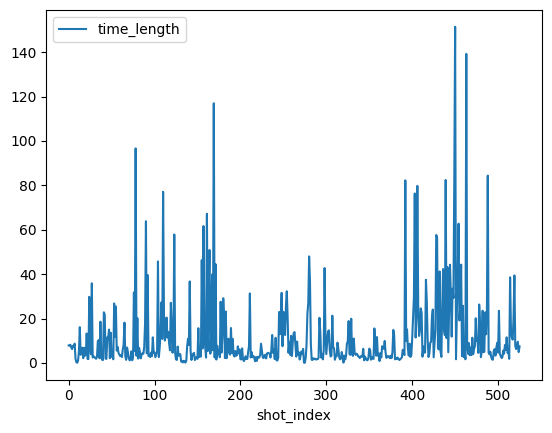

In [51]:
plotline("Xi yan")

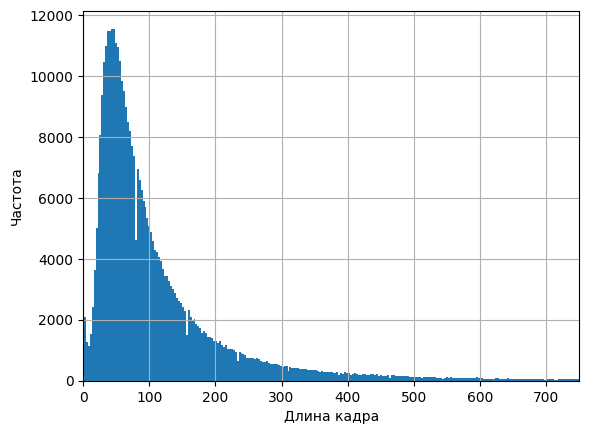

In [52]:
ax = films_data_filt['length'].hist(bins=4000)
ax.set_xlim(0, 750)
plt.xlabel('Длина кадра')
plt.ylabel('Частота')
plt.show()

In [53]:
print('minimum: ', films_data_filt['length'].min())
print('maximum: ', films_data_filt['length'].max())
print('mean: ', films_data_filt['length'].mean())
print('median', films_data_filt['length'].median())
print('standard deviation', films_data_filt['length'].std())

minimum:  1
maximum:  11848
mean:  124.71597702556569
median 76.0
standard deviation 177.23463481199474


In [54]:
def mean_plot(df, column_name):
    ax = df.groupby(column_name)['length'].mean().plot.bar()
    plt.xlabel(column_name)
    plt.ylabel('mean')
    plt.show()

In [55]:
mean_plot(films_data_filt, 'year')

KeyError: 'year'

In [ ]:
mean_plot(films_data_filt, 'genre')

In [ ]:
mean_plot(films_data_filt, 'mark')